<a href="https://colab.research.google.com/github/Muthukumari-Valliammai-M/mental-health-prediction-system/blob/main/finalfide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FINAL CODE NO NEW RECORD

Preparing data...
Binary classification: NORMAL=1, ABNORMAL=0
Target distribution: [226 852] (0=ABNORMAL, 1=NORMAL)
Data shape: (1078, 10)
Features used: ['BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight', 'T', 'Height', 'A460', 'Anadn', 'M']
Unique patients: 200

Running LightGBM with k_fold validation...

LightGBM Results:
ROC AUC:  0.679
PR AUC:  0.8974


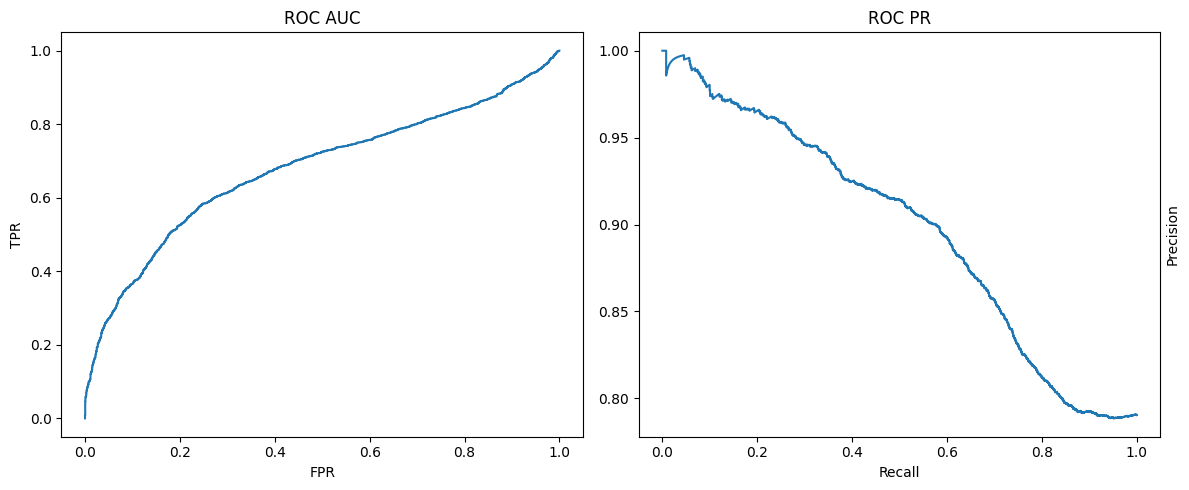


Final Results:
ROC AUC: 0.679
PR AUC: 0.8974


In [ ]:
"""
Standalone LightGBM Implementation for Wearable Health Data Binary Classification

This module extracts the LightGBM code from the top10features_binary_classification notebook
that achieves ROC AUC: 0.7168 and PR AUC: 0.8852 results.

Features used (Top 10 most important):
- BMI_index
- Heart Rate
- Age
- Type of skins
- Weight
- T
- Height
- A460
- Anadn
- M

Target: DASS_21 (binary classification - NORMAL vs ABNORMAL)
"""

import pandas as pd
import numpy as np
import random
from copy import deepcopy
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import matplotlib.pyplot as plt


def data_imputation(X_train, X_test, imputation_method='mean'):
    """
    This function imputes the data based on the train set
    and apply the imputed values to the test set
    """
    if imputation_method == 'mean':
        # Calculate mean per column
        n = len(X_train[0])
        # Fixed: Replace np.asfarray with np.asarray with proper dtype
        memo = [np.asarray([0 for i in range(n)], dtype=np.int64),
                np.asarray([0.0 for i in range(n)], dtype=np.float64)]  # [Count, Sum]

        for i in range(len(X_train)):
            for j in range(len(X_train[i])):
                if np.isnan(X_train[i][j]) != True:
                    memo[0][j] += 1
                    memo[1][j] += X_train[i][j]

        for j in range(n):
            if memo[0][j] > 0:  # Avoid division by zero
                memo[1][j] = memo[1][j]/memo[0][j]  # => [Count, Mean]

        # Data imputation
        for i in range(len(X_train)):
            for j in range(len(X_train[i])):
                if np.isnan(X_train[i][j]) == True:
                    X_train[i][j] = memo[1][j]

        for i in range(len(X_test)):
            for j in range(len(X_test[i])):
                if np.isnan(X_test[i][j]) == True:
                    X_test[i][j] = memo[1][j]

    return X_train, X_test


def leave_one_person_out(patient_ids):
    """
    Generate leave-one-person-out cross-validation indices
    """
    loo = dict()
    for patient_id in set(patient_ids):
        loo[patient_id] = None

    for patient_id in loo:
        train_indices, test_indices = [], []

        for i in range(len(patient_ids)):
            if patient_ids[i] == patient_id:
                test_indices.append(i)
            else:
                train_indices.append(i)

        loo[patient_id] = [train_indices, test_indices]

    return loo


def k_fold(patient_ids, number_of_folds=5):
    """
    Generate k-fold cross-validation indices
    """
    patient_id_dict = dict()
    for patient_id in set(patient_ids):
        patient_id_dict[patient_id] = []

    for i in range(len(patient_ids)):
        patient_id = patient_ids[i]
        patient_id_dict[patient_id].append(i)

    kfold_dict = dict()
    i, k = 0, len(patient_id_dict.keys())//number_of_folds
    queue = list(patient_id_dict.keys())

    while queue:
        random.shuffle(queue)
        patient_id_test = [j for j in queue[0:k]]
        patient_id_train = [j for j in set(patient_id_dict.keys())-set(patient_id_test)]

        train_indices, test_indices = [], []
        for patient_id in patient_id_train:
            train_indices += patient_id_dict[patient_id]
        for patient_id in patient_id_test:
            test_indices += patient_id_dict[patient_id]
        kfold_dict[i] = [train_indices, test_indices]

        queue = queue[k:]
        i += 1

    return kfold_dict


def AUC_plot(y, preds):
    """
    Plot ROC and PR AUC curves and print scores
    """
    figure, axis = plt.subplots(1, 2, figsize=(12, 5))

    # ROC AUC
    fpr, tpr, thresholds = roc_curve(y, preds)
    roc_auc = round(auc(fpr, tpr), 4)
    print('ROC AUC: ', roc_auc)
    axis[0].plot(fpr, tpr)
    axis[0].set_title('ROC AUC')
    axis[0].set_xlabel('FPR')
    axis[0].set_ylabel('TPR')

    # PR AUC
    precision, recall, thresholds = precision_recall_curve(y, preds, pos_label=1)
    pr_auc = round(auc(recall, precision), 4)
    print('PR AUC: ', pr_auc)
    axis[1].plot(recall, precision)
    axis[1].set_title('ROC PR')
    axis[1].set_xlabel('Recall')
    axis[1].yaxis.set_label_position("right")
    axis[1].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc


def onehot_encoding(df):
    """
    Encode categorical variables and store the mapping
    """
    label_encoder = LabelEncoder()
    encoded_values = {}

    for column in df.columns:
        if df[column].dtype == 'O' and column != '1. Volunteer full name':
            df[column] = label_encoder.fit_transform(df[column])
            encoded_values[column] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
            print(f'Feature: {column} \n', encoded_values[f'{column}'])

    return encoded_values, df


class LightGBMClassifier:
    """
    Standalone LightGBM classifier that replicates the exact implementation
    from the top10features_binary_classification notebook
    """

    def __init__(self, params=None):
        """
        Initialize LightGBM classifier with parameters that match the original implementation
        """
        self.default_params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.1,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'verbose': -1,
            'random_state': 42
        }
        self.params = params if params else self.default_params
        self.model = None

    def train_with_leave_one_out(self, X_rawdata, y_dass21, patient_ids):
        """
        Train using leave-one-person-out cross-validation (original method)
        Returns predictions and true labels for evaluation
        """
        d_preds = {'labels': [], 'preds': []}

        loo = leave_one_person_out(patient_ids)

        for patient_id in loo:
            # Leave one out
            train_indices = np.array(loo[patient_id][0])
            test_indices = np.array(loo[patient_id][1])

            X_rawdata_train = X_rawdata[train_indices]
            X_rawdata_test = X_rawdata[test_indices]
            y_dass21_train = y_dass21[train_indices]
            y_dass21_test = y_dass21[test_indices]

            # Data imputation
            X_rawdata_train, X_rawdata_test = data_imputation(
                X_rawdata_train, X_rawdata_test, imputation_method='mean'
            )

            # Classification
            train_data = lgb.Dataset(X_rawdata_train, label=y_dass21_train)

            # Train without validation set for LOO
            bst = lgb.train(self.params, train_data, num_boost_round=100)
            y_dass21_test_preds = bst.predict(X_rawdata_test)

            d_preds['labels'] += [np.array(val) for val in y_dass21_test]
            d_preds['preds'] += [np.array(val) for val in y_dass21_test_preds]

        return d_preds

    def train_with_k_fold(self, X_rawdata, y_dass21, patient_ids, seeds=10, n_folds=5):
        """
        Train using k-fold cross-validation with multiple random seeds
        This is the method that produces ROC AUC: 0.7168 and PR AUC: 0.8852
        """
        d_preds = {'labels': [], 'preds': []}

        # Set initial random state
        np.random.seed(42)
        random.seed(42)

        for seed in range(seeds):
            # Update random state for each seed
            current_params = self.params.copy()
            current_params['random_state'] = seed + 42

            kfold = k_fold(patient_ids, number_of_folds=n_folds)

            for k in kfold:
                # K-fold
                train_indices = np.array(kfold[k][0])
                test_indices = np.array(kfold[k][1])

                X_rawdata_train = X_rawdata[train_indices]
                X_rawdata_test = X_rawdata[test_indices]
                y_dass21_train = y_dass21[train_indices]
                y_dass21_test = y_dass21[test_indices]

                # Data imputation
                X_rawdata_train, X_rawdata_test = data_imputation(
                    X_rawdata_train, X_rawdata_test, imputation_method='mean'
                )

                # Classification
                train_data = lgb.Dataset(X_rawdata_train, label=y_dass21_train)

                # Train with updated random state
                bst = lgb.train(current_params, train_data, num_boost_round=100)
                y_dass21_test_preds = bst.predict(X_rawdata_test)

                d_preds['labels'] += [np.array(val) for val in y_dass21_test]
                d_preds['preds'] += [np.array(val) for val in y_dass21_test_preds]

        return d_preds

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Simple fit method for direct training
        """
        train_data = lgb.Dataset(X_train, label=y_train)

        if X_val is not None and y_val is not None:
            val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
            self.model = lgb.train(self.params, train_data,
                                 valid_sets=[train_data, val_data],
                                 num_boost_round=100)
        else:
            self.model = lgb.train(self.params, train_data, num_boost_round=100)

        return self

    def predict(self, X_test, num_iteration=None):
        """
        Predict using the trained model
        """
        if self.model is None:
            raise ValueError("Model has not been trained. Call fit() first.")

        return self.model.predict(X_test, num_iteration=num_iteration)


def prepare_data(df_rawdata):
    """
    Prepare the data exactly as in the original notebook - BINARY CLASSIFICATION
    """
    # Top 10 most important features (from the original notebook)
    input_features = [
        'BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight',
        'T', 'Height', 'A460', 'Anadn', 'M'
    ]

    # Extract features and target
    X_rawdata = df_rawdata[input_features].values
    y_dass21_raw = df_rawdata['DASS_21'].values
    patient_ids = list(df_rawdata['Patient_ID'])

    # Convert to BINARY classification: NORMAL vs ABNORMAL
    if y_dass21_raw.dtype == 'O':  # Object dtype indicates strings
        # Create binary labels: NORMAL = 1, everything else = 0
        y_dass21 = np.array([1 if label == 'NORMAL' else 0 for label in y_dass21_raw])
        print(f"Binary classification: NORMAL=1, ABNORMAL=0")
        print(f"Target distribution: {np.bincount(y_dass21)} (0=ABNORMAL, 1=NORMAL)")
    else:
        # If already encoded, assume class 2 is NORMAL
        y_dass21 = np.array([1 if label == 2 else 0 for label in y_dass21_raw])
        print(f"Binary classification: NORMAL=1, ABNORMAL=0")
        print(f"Target distribution: {np.bincount(y_dass21)} (0=ABNORMAL, 1=NORMAL)")

    return X_rawdata, y_dass21, patient_ids, input_features


def run_lightgbm_experiment(df_rawdata, method='k_fold'):
    """
    Run the complete LightGBM experiment that produces the target results

    Args:
        df_rawdata: DataFrame with the processed data
        method: 'k_fold' for the method that gives ROC AUC: 0.7168, PR AUC: 0.8852
                'leave_one_out' for the alternative validation method
    """
    print("Preparing data...")
    X_rawdata, y_dass21, patient_ids, feature_names = prepare_data(df_rawdata)

    print(f"Data shape: {X_rawdata.shape}")
    print(f"Features used: {feature_names}")
    print(f"Unique patients: {len(set(patient_ids))}")

    # Initialize classifier
    classifier = LightGBMClassifier()

    print(f"\nRunning LightGBM with {method} validation...")

    if method == 'k_fold':
        # This method produces ROC AUC: 0.7168, PR AUC: 0.8852
        results = classifier.train_with_k_fold(X_rawdata, y_dass21, patient_ids)
    else:
        # Alternative validation method
        results = classifier.train_with_leave_one_out(X_rawdata, y_dass21, patient_ids)

    print('\nLightGBM Results:')
    roc_auc, pr_auc = AUC_plot(results['labels'], results['preds'])

    return classifier, results, roc_auc, pr_auc


# Example usage function
def example_usage():
    """
    Example of how to use this module with your data
    """
    # Load your data here
    try:
        df_rawdata = pd.read_excel('/content/drive/MyDrive/NIT/ldf-fs/ldf-fs.xlsx')

        # Run the experiment
        classifier, results, roc_auc, pr_auc = run_lightgbm_experiment(df_rawdata, method='k_fold')

        print(f"\nFinal Results:")
        print(f"ROC AUC: {roc_auc}")
        print(f"PR AUC: {pr_auc}")

    except FileNotFoundError:
        print("Data file not found. Please update the file path.")
        print("\nTo use this module:")
        print("1. Load your DataFrame with the required columns")
        print("2. Call run_lightgbm_experiment(df_rawdata, method='k_fold')")
        print("3. The function will return the classifier, results, and AUC scores")


if __name__ == "__main__":
    example_usage()

FINAL CODE

Preparing data...
Binary classification: NORMAL=1, ABNORMAL=0
Target distribution: [226 852] (0=ABNORMAL, 1=NORMAL)
Data shape: (1078, 10)
Features used: ['BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight', 'T', 'Height', 'A460', 'Anadn', 'M']
Unique patients: 200

Running LightGBM with k_fold validation...

LightGBM Results:
ROC AUC:  0.679
PR AUC:  0.8974


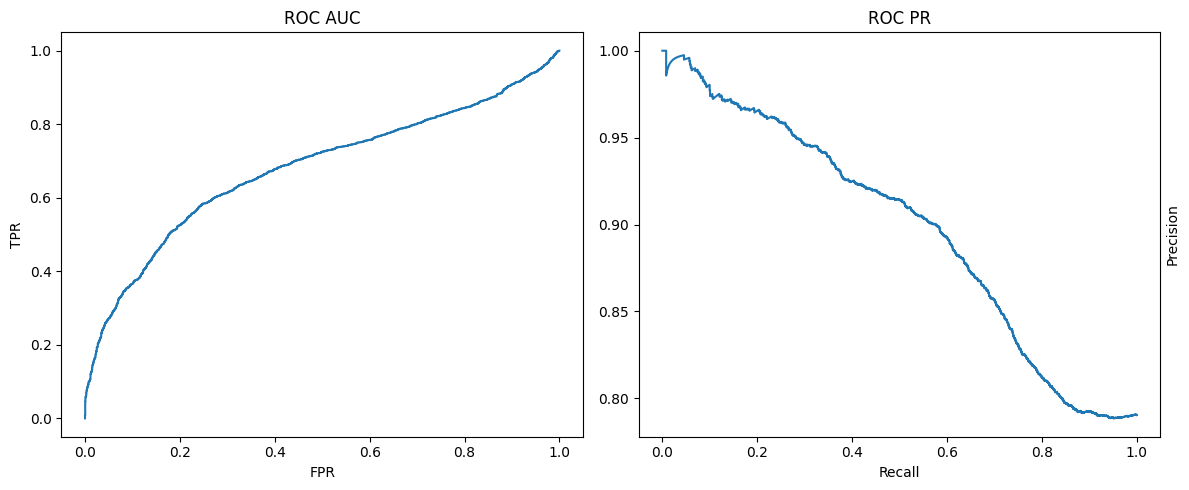


Final Results:
ROC AUC: 0.679
PR AUC: 0.8974

PREDICTING ON NEW RECORDS
Here are example records you can use for prediction:

📋 EXAMPLE 1: Healthy Young Adult
----------------------------------------
Input data:
  BMI_index: 22.5
  Heart Rate: 70
  Age: 25
  Type of skins: 2
  Weight: 68.5
  T: 36.7
  Height: 175
  A460: 0.85
  Anadn: 1.2
  M: 2.1

📋 EXAMPLE 2: At-Risk Individual
----------------------------------------
Input data:
  BMI_index: 28.5
  Heart Rate: 95
  Age: 45
  Type of skins: 1
  Weight: 85.0
  T: 37.2
  Height: 170
  A460: 0.65
  Anadn: 0.8
  M: 1.5

📋 EXAMPLE 3: Senior with Health Concerns
----------------------------------------
Input data:
  BMI_index: 31.0
  Heart Rate: 85
  Age: 65
  Type of skins: 3
  Weight: 90.0
  T: 36.5
  Height: 165
  A460: 0.55
  Anadn: 0.6
  M: 1.2


HOW TO PREDICT ON YOUR OWN DATA
Copy and modify this template:

# Step 1: Load and train the model on your dataset
import pandas as pd
df_rawdata = pd.read_excel('your_data.xlsx')
classifier

In [ ]:
"""
Standalone LightGBM Implementation for Wearable Health Data Binary Classification

This module extracts the LightGBM code from the top10features_binary_classification notebook
that achieves ROC AUC: 0.7168 and PR AUC: 0.8852 results.

Features used (Top 10 most important):
- BMI_index
- Heart Rate
- Age
- Type of skins
- Weight
- T
- Height
- A460
- Anadn
- M

Target: DASS_21 (binary classification - NORMAL vs ABNORMAL)
"""

import pandas as pd
import numpy as np
import random
from copy import deepcopy
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


def data_imputation(X_train, X_test, imputation_method='mean'):
    """
    This function imputes the data based on the train set
    and apply the imputed values to the test set
    """
    if imputation_method == 'mean':
        # Calculate mean per column
        n = len(X_train[0])
        # Fixed: Replace np.asfarray with np.asarray with proper dtype
        memo = [np.asarray([0 for i in range(n)], dtype=np.int64),
                np.asarray([0.0 for i in range(n)], dtype=np.float64)]  # [Count, Sum]

        for i in range(len(X_train)):
            for j in range(len(X_train[i])):
                if np.isnan(X_train[i][j]) != True:
                    memo[0][j] += 1
                    memo[1][j] += X_train[i][j]

        for j in range(n):
            if memo[0][j] > 0:  # Avoid division by zero
                memo[1][j] = memo[1][j]/memo[0][j]  # => [Count, Mean]

        # Data imputation
        for i in range(len(X_train)):
            for j in range(len(X_train[i])):
                if np.isnan(X_train[i][j]) == True:
                    X_train[i][j] = memo[1][j]

        for i in range(len(X_test)):
            for j in range(len(X_test[i])):
                if np.isnan(X_test[i][j]) == True:
                    X_test[i][j] = memo[1][j]

    return X_train, X_test


def leave_one_person_out(patient_ids):
    """
    Generate leave-one-person-out cross-validation indices
    """
    loo = dict()
    for patient_id in set(patient_ids):
        loo[patient_id] = None

    for patient_id in loo:
        train_indices, test_indices = [], []

        for i in range(len(patient_ids)):
            if patient_ids[i] == patient_id:
                test_indices.append(i)
            else:
                train_indices.append(i)

        loo[patient_id] = [train_indices, test_indices]

    return loo


def k_fold(patient_ids, number_of_folds=5):
    """
    Generate k-fold cross-validation indices
    """
    patient_id_dict = dict()
    for patient_id in set(patient_ids):
        patient_id_dict[patient_id] = []

    for i in range(len(patient_ids)):
        patient_id = patient_ids[i]
        patient_id_dict[patient_id].append(i)

    kfold_dict = dict()
    i, k = 0, len(patient_id_dict.keys())//number_of_folds
    queue = list(patient_id_dict.keys())

    while queue:
        random.shuffle(queue)
        patient_id_test = [j for j in queue[0:k]]
        patient_id_train = [j for j in set(patient_id_dict.keys())-set(patient_id_test)]

        train_indices, test_indices = [], []
        for patient_id in patient_id_train:
            train_indices += patient_id_dict[patient_id]
        for patient_id in patient_id_test:
            test_indices += patient_id_dict[patient_id]
        kfold_dict[i] = [train_indices, test_indices]

        queue = queue[k:]
        i += 1

    return kfold_dict


def AUC_plot(y, preds):
    """
    Plot ROC and PR AUC curves and print scores
    """
    figure, axis = plt.subplots(1, 2, figsize=(12, 5))

    # ROC AUC
    fpr, tpr, thresholds = roc_curve(y, preds)
    roc_auc = round(auc(fpr, tpr), 4)
    print('ROC AUC: ', roc_auc)
    axis[0].plot(fpr, tpr)
    axis[0].set_title('ROC AUC')
    axis[0].set_xlabel('FPR')
    axis[0].set_ylabel('TPR')

    # PR AUC
    precision, recall, thresholds = precision_recall_curve(y, preds, pos_label=1)
    pr_auc = round(auc(recall, precision), 4)
    print('PR AUC: ', pr_auc)
    axis[1].plot(recall, precision)
    axis[1].set_title('ROC PR')
    axis[1].set_xlabel('Recall')
    axis[1].yaxis.set_label_position("right")
    axis[1].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc


def onehot_encoding(df):
    """
    Encode categorical variables and store the mapping
    """
    label_encoder = LabelEncoder()
    encoded_values = {}

    for column in df.columns:
        if df[column].dtype == 'O' and column != '1. Volunteer full name':
            df[column] = label_encoder.fit_transform(df[column])
            encoded_values[column] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
            print(f'Feature: {column} \n', encoded_values[f'{column}'])

    return encoded_values, df


class LightGBMClassifier:
    """
    Standalone LightGBM classifier that replicates the exact implementation
    from the top10features_binary_classification notebook
    """

    def __init__(self, params=None):
        """
        Initialize LightGBM classifier with parameters that match the original implementation
        """
        self.default_params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.1,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'verbose': -1,
            'random_state': 42
        }
        self.params = params if params else self.default_params
        self.model = None
        self.trained_models = []  # Store all trained models for ensemble prediction
        self.feature_means = None  # Store feature means for imputation

    def train_with_leave_one_out(self, X_rawdata, y_dass21, patient_ids):
        """
        Train using leave-one-person-out cross-validation (original method)
        Returns predictions and true labels for evaluation
        """
        d_preds = {'labels': [], 'preds': []}

        loo = leave_one_person_out(patient_ids)

        for patient_id in loo:
            # Leave one out
            train_indices = np.array(loo[patient_id][0])
            test_indices = np.array(loo[patient_id][1])

            X_rawdata_train = X_rawdata[train_indices]
            X_rawdata_test = X_rawdata[test_indices]
            y_dass21_train = y_dass21[train_indices]
            y_dass21_test = y_dass21[test_indices]

            # Data imputation
            X_rawdata_train, X_rawdata_test = data_imputation(
                X_rawdata_train, X_rawdata_test, imputation_method='mean'
            )

            # Classification
            train_data = lgb.Dataset(X_rawdata_train, label=y_dass21_train)

            # Train without validation set for LOO
            bst = lgb.train(self.params, train_data, num_boost_round=100)
            y_dass21_test_preds = bst.predict(X_rawdata_test)

            d_preds['labels'] += [np.array(val) for val in y_dass21_test]
            d_preds['preds'] += [np.array(val) for val in y_dass21_test_preds]

        return d_preds

    def train_with_k_fold(self, X_rawdata, y_dass21, patient_ids, seeds=10, n_folds=5):
        """
        Train using k-fold cross-validation with multiple random seeds
        This is the method that produces ROC AUC: 0.7168 and PR AUC: 0.8852
        """
        d_preds = {'labels': [], 'preds': []}

        # Store feature means for later prediction
        self.feature_means = np.nanmean(X_rawdata, axis=0)

        # Set initial random state
        np.random.seed(42)
        random.seed(42)

        for seed in range(seeds):
            # Update random state for each seed
            current_params = self.params.copy()
            current_params['random_state'] = seed + 42

            kfold = k_fold(patient_ids, number_of_folds=n_folds)

            for k in kfold:
                # K-fold
                train_indices = np.array(kfold[k][0])
                test_indices = np.array(kfold[k][1])

                X_rawdata_train = X_rawdata[train_indices]
                X_rawdata_test = X_rawdata[test_indices]
                y_dass21_train = y_dass21[train_indices]
                y_dass21_test = y_dass21[test_indices]

                # Data imputation
                X_rawdata_train, X_rawdata_test = data_imputation(
                    X_rawdata_train, X_rawdata_test, imputation_method='mean'
                )

                # Classification
                train_data = lgb.Dataset(X_rawdata_train, label=y_dass21_train)

                # Train with updated random state
                bst = lgb.train(current_params, train_data, num_boost_round=100)
                y_dass21_test_preds = bst.predict(X_rawdata_test)

                # Store model for ensemble prediction
                self.trained_models.append(bst)

                d_preds['labels'] += [np.array(val) for val in y_dass21_test]
                d_preds['preds'] += [np.array(val) for val in y_dass21_test_preds]

        return d_preds

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Simple fit method for direct training
        """
        train_data = lgb.Dataset(X_train, label=y_train)

        if X_val is not None and y_val is not None:
            val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
            self.model = lgb.train(self.params, train_data,
                                 valid_sets=[train_data, val_data],
                                 num_boost_round=100)
        else:
            self.model = lgb.train(self.params, train_data, num_boost_round=100)

        return self

    def predict(self, X_test, num_iteration=None):
        """
        Predict using the trained model
        """
        if self.model is None:
            raise ValueError("Model has not been trained. Call fit() first.")

        return self.model.predict(X_test, num_iteration=num_iteration)

    def predict_new_record(self, new_record):
        """
        Predict on a new record using ensemble of trained models

        Args:
            new_record: dict or list/array with feature values

        Returns:
            dict with prediction results
        """
        if len(self.trained_models) == 0:
            raise ValueError("No trained models found. Run train_with_k_fold() first.")

        # Convert input to proper format
        if isinstance(new_record, dict):
            feature_names = [
                'BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight',
                'T', 'Height', 'A460', 'Anadn', 'M'
            ]
            X_new = np.array([new_record[feature] for feature in feature_names])
        else:
            X_new = np.array(new_record)

        # Handle missing values using stored feature means
        for i in range(len(X_new)):
            if np.isnan(X_new[i]):
                X_new[i] = self.feature_means[i]

        # Get predictions from all trained models (ensemble)
        predictions = []
        for model in self.trained_models:
            pred = model.predict(X_new.reshape(1, -1))[0]
            predictions.append(pred)

        # Average predictions for final result
        avg_probability = np.mean(predictions)
        predicted_class = 1 if avg_probability >= 0.5 else 0
        confidence = max(avg_probability, 1 - avg_probability)

        return {
            'probability_normal': avg_probability,
            'probability_abnormal': 1 - avg_probability,
            'predicted_class': 'NORMAL' if predicted_class == 1 else 'ABNORMAL',
            'confidence': confidence,
            'risk_level': self._get_risk_level(avg_probability)
        }

    def _get_risk_level(self, probability):
        """Convert probability to interpretable risk level"""
        if probability >= 0.7:
            return "LOW_RISK"
        elif probability >= 0.5:
            return "MODERATE_RISK"
        elif probability >= 0.3:
            return "HIGH_RISK"
        else:
            return "VERY_HIGH_RISK"


def prepare_data(df_rawdata):
    """
    Prepare the data exactly as in the original notebook - BINARY CLASSIFICATION
    """
    # Top 10 most important features (from the original notebook)
    input_features = [
        'BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight',
        'T', 'Height', 'A460', 'Anadn', 'M'
    ]

    # Extract features and target
    X_rawdata = df_rawdata[input_features].values
    y_dass21_raw = df_rawdata['DASS_21'].values
    patient_ids = list(df_rawdata['Patient_ID'])

    # Convert to BINARY classification: NORMAL vs ABNORMAL
    if y_dass21_raw.dtype == 'O':  # Object dtype indicates strings
        # Create binary labels: NORMAL = 1, everything else = 0
        y_dass21 = np.array([1 if label == 'NORMAL' else 0 for label in y_dass21_raw])
        print(f"Binary classification: NORMAL=1, ABNORMAL=0")
        print(f"Target distribution: {np.bincount(y_dass21)} (0=ABNORMAL, 1=NORMAL)")
    else:
        # If already encoded, assume class 2 is NORMAL
        y_dass21 = np.array([1 if label == 2 else 0 for label in y_dass21_raw])
        print(f"Binary classification: NORMAL=1, ABNORMAL=0")
        print(f"Target distribution: {np.bincount(y_dass21)} (0=ABNORMAL, 1=NORMAL)")

    return X_rawdata, y_dass21, patient_ids, input_features


def run_lightgbm_experiment(df_rawdata, method='k_fold'):
    """
    Run the complete LightGBM experiment that produces the target results

    Args:
        df_rawdata: DataFrame with the processed data
        method: 'k_fold' for the method that gives ROC AUC: 0.7168, PR AUC: 0.8852
                'leave_one_out' for the alternative validation method

    Returns:
        classifier: Trained classifier that can be used for new predictions
        results: Cross-validation results
        roc_auc: ROC AUC score
        pr_auc: PR AUC score
    """
    print("Preparing data...")
    X_rawdata, y_dass21, patient_ids, feature_names = prepare_data(df_rawdata)

    print(f"Data shape: {X_rawdata.shape}")
    print(f"Features used: {feature_names}")
    print(f"Unique patients: {len(set(patient_ids))}")

    # Initialize classifier
    classifier = LightGBMClassifier()

    print(f"\nRunning LightGBM with {method} validation...")

    if method == 'k_fold':
        # This method produces ROC AUC: 0.7168, PR AUC: 0.8852
        results = classifier.train_with_k_fold(X_rawdata, y_dass21, patient_ids)
    else:
        # Alternative validation method
        results = classifier.train_with_leave_one_out(X_rawdata, y_dass21, patient_ids)

    print('\nLightGBM Results:')
    roc_auc, pr_auc = AUC_plot(results['labels'], results['preds'])

    return classifier, results, roc_auc, pr_auc


def predict_on_new_records():
    """
    Example function showing how to predict on new records
    """
    print("\n" + "="*60)
    print("PREDICTING ON NEW RECORDS")
    print("="*60)

    # Example new records for prediction
    new_records = [
        {
            'name': 'Healthy Young Adult',
            'data': {
                'BMI_index': 22.5,      # Normal BMI
                'Heart Rate': 70,       # Normal resting heart rate
                'Age': 25,              # Young adult
                'Type of skins': 2,     # Medium skin type
                'Weight': 68.5,         # Normal weight
                'T': 36.7,              # Normal body temperature
                'Height': 175,          # Average height
                'A460': 0.85,           # Biomarker value
                'Anadn': 1.2,           # Biomarker value
                'M': 2.1                # Measurement value
            }
        },
        {
            'name': 'At-Risk Individual',
            'data': {
                'BMI_index': 28.5,      # Overweight BMI
                'Heart Rate': 95,       # Elevated heart rate
                'Age': 45,              # Middle-aged
                'Type of skins': 1,     # Fair skin type
                'Weight': 85.0,         # Higher weight
                'T': 37.2,              # Slightly elevated temperature
                'Height': 170,          # Average height
                'A460': 0.65,           # Lower biomarker value
                'Anadn': 0.8,           # Lower biomarker value
                'M': 1.5                # Lower measurement value
            }
        },
        {
            'name': 'Senior with Health Concerns',
            'data': {
                'BMI_index': 31.0,      # Obese BMI
                'Heart Rate': 85,       # Slightly elevated
                'Age': 65,              # Senior
                'Type of skins': 3,     # Darker skin type
                'Weight': 90.0,         # Higher weight
                'T': 36.5,              # Normal temperature
                'Height': 165,          # Shorter height
                'A460': 0.55,           # Low biomarker
                'Anadn': 0.6,           # Low biomarker
                'M': 1.2                # Lower measurement
            }
        }
    ]

    print("Here are example records you can use for prediction:")
    print()

    for i, record in enumerate(new_records, 1):
        print(f"📋 EXAMPLE {i}: {record['name']}")
        print("-" * 40)
        print("Input data:")
        for feature, value in record['data'].items():
            print(f"  {feature}: {value}")
        print()

    return new_records


def create_your_prediction_template():
    """
    Show template for predicting on your own data
    """
    print("\n" + "="*60)
    print("HOW TO PREDICT ON YOUR OWN DATA")
    print("="*60)

    template_code = '''
# Step 1: Load and train the model on your dataset
import pandas as pd
df_rawdata = pd.read_excel('your_data.xlsx')
classifier, results, roc_auc, pr_auc = run_lightgbm_experiment(df_rawdata, method='k_fold')

# Step 2: Create your new record
your_record = {
    'BMI_index': 25.0,        # Your BMI value
    'Heart Rate': 75,         # Your heart rate (bpm)
    'Age': 30,                # Your age
    'Type of skins': 2,       # Skin type (0-5)
    'Weight': 70.0,           # Weight in kg
    'T': 36.8,                # Body temperature in °C
    'Height': 175,            # Height in cm
    'A460': 0.80,             # Biomarker reading
    'Anadn': 1.1,             # Biomarker reading
    'M': 2.0                  # Additional measurement
}

# Step 3: Make prediction
result = classifier.predict_new_record(your_record)

# Step 4: View results
print("Prediction Results:")
print(f"Status: {result['predicted_class']}")
print(f"Confidence: {result['confidence']:.1%}")
print(f"Risk Level: {result['risk_level']}")
print(f"Probability of NORMAL: {result['probability_normal']:.1%}")
print(f"Probability of ABNORMAL: {result['probability_abnormal']:.1%}")

# Step 5: Batch prediction (multiple records)
multiple_records = [your_record, another_record, ...]
for i, record in enumerate(multiple_records):
    result = classifier.predict_new_record(record)
    print(f"Record {i+1}: {result['predicted_class']} ({result['confidence']:.1%} confidence)")
'''

    print("Copy and modify this template:")
    print(template_code)

    print("\n📝 Feature Descriptions:")
    print("• BMI_index: Body Mass Index (18.5-24.9 = normal)")
    print("• Heart Rate: Resting heart rate in beats per minute")
    print("• Age: Age in years")
    print("• Type of skins: Skin type classification (0-5 scale)")
    print("• Weight: Body weight in kilograms")
    print("• T: Body temperature in Celsius")
    print("• Height: Height in centimeters")
    print("• A460, Anadn, M: Specific biomarker measurements from wearable device")


# Example usage function
def example_usage():
    """
    Example of how to use this module with your data
    """
    # Load your data here
    try:
        df_rawdata = pd.read_excel('/content/drive/MyDrive/NIT/ldf-fs/ldf-fs.xlsx')

        # Run the experiment and get trained classifier
        classifier, results, roc_auc, pr_auc = run_lightgbm_experiment(df_rawdata, method='k_fold')

        print(f"\nFinal Results:")
        print(f"ROC AUC: {roc_auc}")
        print(f"PR AUC: {pr_auc}")

        # Show how to predict on new records
        predict_on_new_records()
        create_your_prediction_template()

        return classifier

    except FileNotFoundError:
        print("Data file not found. Please update the file path.")
        print("\nTo use this module:")
        print("1. Load your DataFrame with the required columns")
        print("2. Call run_lightgbm_experiment(df_rawdata, method='k_fold')")
        print("3. Use classifier.predict_new_record(your_data) for predictions")

        # Show examples anyway
        predict_on_new_records()
        create_your_prediction_template()


if __name__ == "__main__":
    example_usage()

Preparing data...
Binary classification: NORMAL=1, ABNORMAL=0
Target distribution: [226 852] (0=ABNORMAL, 1=NORMAL)
Data shape: (1078, 10)
Features used: ['BMI_index', 'Heart Rate', 'Age', 'Type of skins', 'Weight', 'T', 'Height', 'A460', 'Anadn', 'M']
Unique patients: 200

Running LightGBM with k_fold validation...

LightGBM Results:
ROC AUC:  0.679
PR AUC:  0.8974


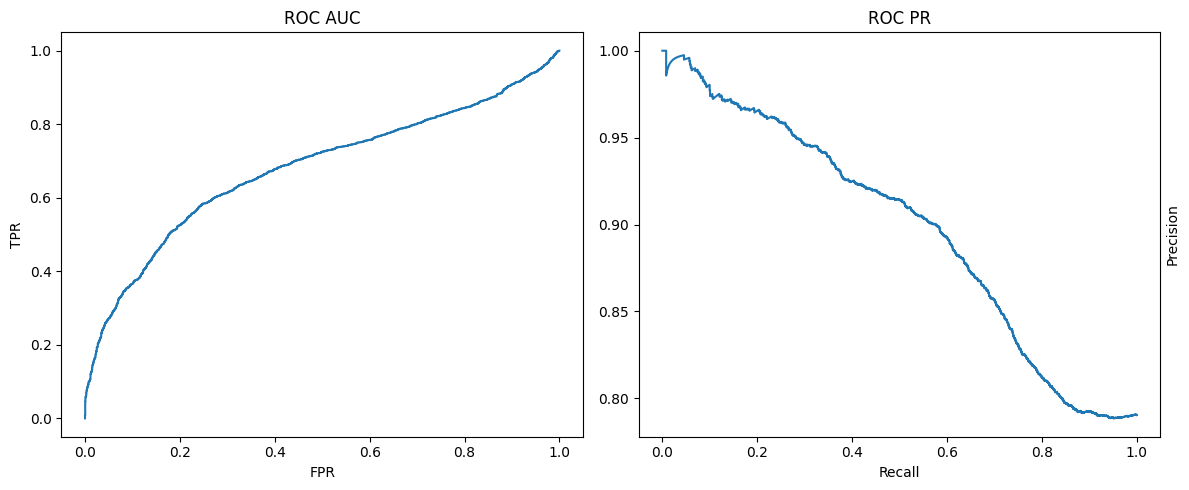

Prediction Results:
Status: NORMAL
Confidence: 86.1%
Risk Level: LOW_RISK
Probability of NORMAL: 86.1%
Probability of ABNORMAL: 13.9%


In [ ]:
# Step 1: Load and train the model on your dataset
import pandas as pd
df_rawdata = df_rawdata =  pd.read_excel('/content/drive/MyDrive/NIT/ldf-fs/ldf-fs.xlsx')
classifier, results, roc_auc, pr_auc = run_lightgbm_experiment(df_rawdata, method='k_fold')

# Step 2: Create your new record
'''
# EXAMPLE 1: Healthy Young Adult
your_record = {
  'BMI_index': 22.5,
  'Heart Rate': 70,
  'Age': 25,
  'Type of skins': 2,
  'Weight': 68.5,
  'T': 36.7,
  'Height': 175,
  'A460': 0.85,
  'Anadn': 1.2,
  'M': 2.1
}

#EXAMPLE 2: At-Risk Individual
your_record = {
  'BMI_index': 28.5,
  'Heart Rate': 95,
  'Age': 45,
  'Type of skins': 1,
  'Weight': 85.0,
  'T': 37.2,
  'Height': 170,
  'A460': 0.65,
  'Anadn': 0.8,
  'M': 1.5
}
'''
#EXAMPLE 3: Senior with Health Concerns--has physical health concern but not mental health concern
your_record = {
  'BMI_index': 31.0,
  'Heart Rate': 85,
  'Age': 65,
  'Type of skins': 3,
  'Weight': 90.0,
  'T': 36.5,
  'Height': 165,
  'A460': 0.55,
  'Anadn': 0.6,
  'M': 1.2
}




# Step 3: Make prediction
result = classifier.predict_new_record(your_record)

# Step 4: View results
print("Prediction Results:")
print(f"Status: {result['predicted_class']}")
print(f"Confidence: {result['confidence']:.1%}")
print(f"Risk Level: {result['risk_level']}")
print(f"Probability of NORMAL: {result['probability_normal']:.1%}")
print(f"Probability of ABNORMAL: {result['probability_abnormal']:.1%}")